In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
mutac_df = pd.read_feather("../data/joined-counts.20x-cov.na-filled.zstd-8.feather")
mutac_df.shape

(18822594, 179)

In [13]:
col_ler_diff_df = pd.read_csv("../data/col_ler_diff_table.csv", index_col=0)
col_ler_diff_df.shape

(126817, 2)

In [8]:
df = mutac_df.join(
    col_ler_diff_df,
    how="inner"
)
df.to_csv("../data/col-ler-diff.mutac.csv")
df.shape

(68118, 181)

In [2]:
df = pd.read_csv("../data/col-ler-diff.mutac.csv", index_col=0)
df.shape

(68118, 181)

In [9]:
df.head()

,SRR6862404,SRR6862406,SRR6862407,SRR6862408,SRR6862409,SRR6862410,SRR6862411,SRR6862412,SRR6862413,SRR6862414,...,SRR6750181,SRR6750188,SRR6750190,SRR6750191,SRR6750192,SRR6750193,SRR6750194,SRR6750204,col.tsv,ler.tsv
kmer,,,,,,,,,,,,,,,,,,,,,
AAAAAAAAAAAAAAAAAAAAAAC,1221.31410,1329.3580,1263.65500,1281.39970,1361.98830,1262.00950,1322.45310,1182.02230,1394.00620,1425.06680,...,1209.52030,1216.70340,1413.9263,1441.83350,1250.50740,1380.73250,1287.09230,1352.95590,0,8624
AAAAAAAAAAAAAAAAAAAAACA,791.78530,814.4264,781.37976,780.18787,845.65940,795.91600,816.34080,750.72970,885.05963,911.31330,...,714.31160,810.89905,913.9512,932.43290,788.39850,871.09630,811.67175,858.06370,0,3506
AAAAAAAAAAAAAAAAAAAACAA,644.46230,635.1989,616.89400,613.35290,669.55634,634.91380,647.07410,601.29010,714.73236,730.00543,...,551.70010,659.48640,748.0445,767.07104,631.08826,700.46924,655.20800,687.19525,0,1978
AAAAAAAAAAAAAAAAAAACAAA,599.16327,588.0212,570.25397,567.77466,621.02710,592.67755,602.88556,563.83795,665.07245,679.78534,...,516.61880,616.98096,702.2203,718.87695,586.56110,655.33826,621.88830,646.32996,0,1710
AAAAAAAAAAAAAAAAAACAAAA,571.07117,556.5534,544.64545,540.61380,591.46674,569.28570,576.39844,545.07230,643.86066,651.74740,...,497.58142,589.69690,679.3663,693.43494,561.97970,634.12440,605.32764,620.02875,0,1471


In [ ]:
df

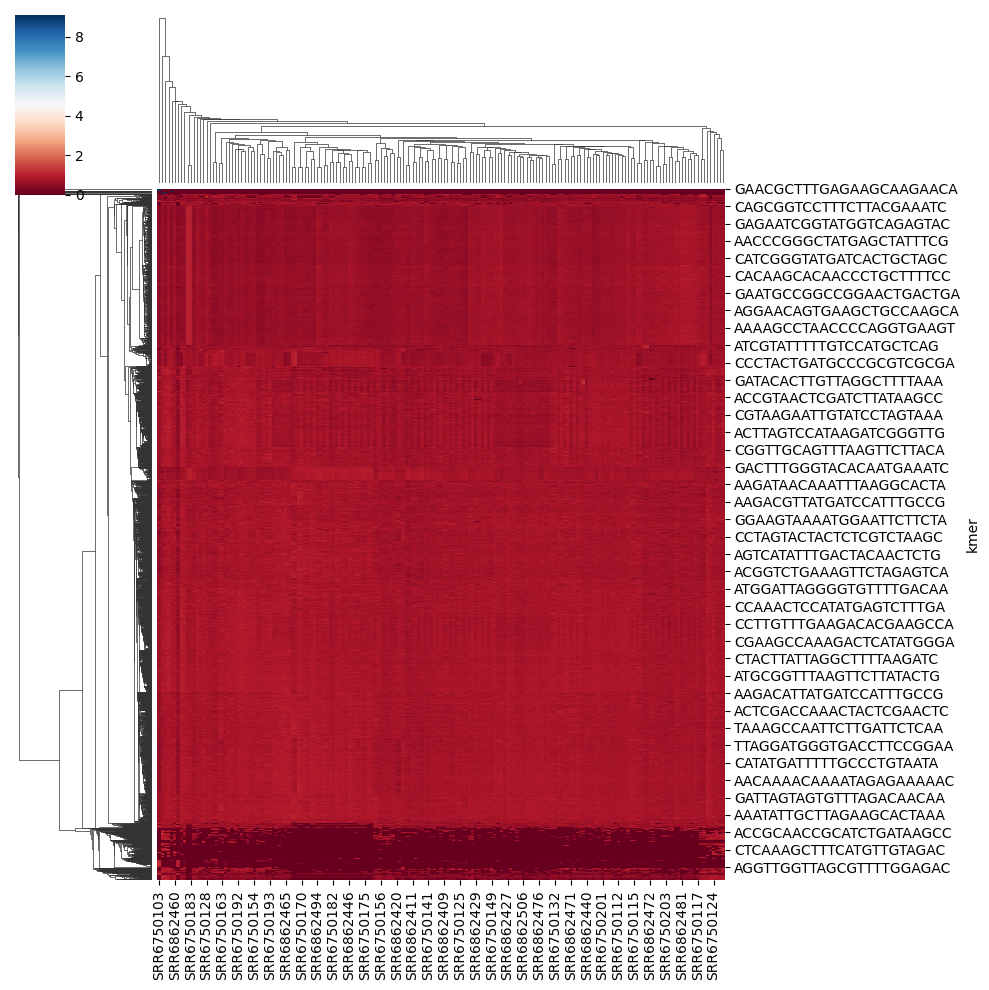

In [10]:
sample = df.drop(columns=["col.tsv", "ler.tsv"]).sample(4096)

sns.clustermap(
    sample.div(sample.quantile(0.995, axis=1), axis=0),
    cmap="RdBu"
)

In [11]:
df.shape

(68118, 181)

In [12]:
mutac_df3 = pd.read_feather("../data/joined-counts.df3.zstd8.feather")
mutac_df3.shape

(216196, 179)

In [16]:
mutac_df3_col_ler_diff_df = mutac_df3.join(
    col_ler_diff_df,
    how="inner"
)

mutac_df3_col_ler_diff_df.to_csv("../data/col-ler-diff.mutac.df3.csv")
mutac_df3_col_ler_diff_df.shape

(601, 181)

In [15]:
mutac_df3_col_ler_diff_df

,SRR6862404,SRR6862406,SRR6862407,SRR6862408,SRR6862409,SRR6862410,SRR6862411,SRR6862412,SRR6862413,SRR6862414,...,SRR6750181,SRR6750188,SRR6750190,SRR6750191,SRR6750192,SRR6750193,SRR6750194,SRR6750204,col.tsv,ler.tsv
kmer,,,,,,,,,,,,,,,,,,,,,
AAAAAAAAAAAAAGAATCACTCA,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.368482,...,1.058645,0.000000,1.301958,1.277705,0.000000,0.000000,0.000000,1.681846,0,483
AAAAAAAAAAAAGAATCACTCAT,0.000000,0.957923,1.216696,1.339442,1.475845,1.214759,1.211830,1.001535,1.221146,1.909509,...,1.514958,0.000000,1.673946,1.636358,1.012384,1.191274,1.011491,2.504878,0,4009
AAAAAAAATAAGTAATACAATTA,1.893091,0.000000,1.100821,1.376649,0.000000,1.308202,0.000000,1.265097,1.447284,1.241181,...,0.000000,1.808254,1.208961,1.143209,1.101190,0.000000,0.000000,1.073519,0,3423
AAAAAAATAAGTAATACAATTAT,1.893091,0.957923,1.100821,1.376649,0.998366,1.214759,0.000000,1.265097,1.402057,1.241181,...,0.000000,1.876922,1.208961,1.143209,1.118951,0.000000,0.000000,0.966167,0,3442
AAAAAACTAACAAACCTTCTTCT,2.062117,1.867950,1.245665,1.190615,1.953325,1.121316,1.558068,1.317809,1.311602,2.004985,...,0.000000,3.799623,2.115681,2.353666,1.882679,1.557820,0.000000,1.431359,0,372
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTCTTCTCCAAAACACTAACCAA,2.535390,1.724262,1.274634,1.748716,1.909918,1.557383,1.428228,1.581371,0.995008,1.559433,...,0.000000,5.195870,2.371423,2.532993,2.095813,1.832729,0.000000,2.111254,0,128
TTGACTTTGGCTACAACATGAAA,2.433974,1.628470,1.187727,1.227822,1.475845,0.000000,0.000000,1.317809,1.537740,1.082055,...,0.000000,3.227391,1.883189,1.995012,1.935962,1.741093,0.000000,1.574494,0,300
TTGTTAGAAGAAAAAAAGCCAAA,2.839637,1.867950,2.433393,2.678884,2.951691,2.336074,3.029576,2.055783,2.668431,3.118865,...,0.000000,5.195870,3.394390,3.564123,3.250286,3.207277,0.000000,3.864668,0,113
